In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'coins.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(312, 252, 3)

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
t_otsu, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
t_otsu

162.0

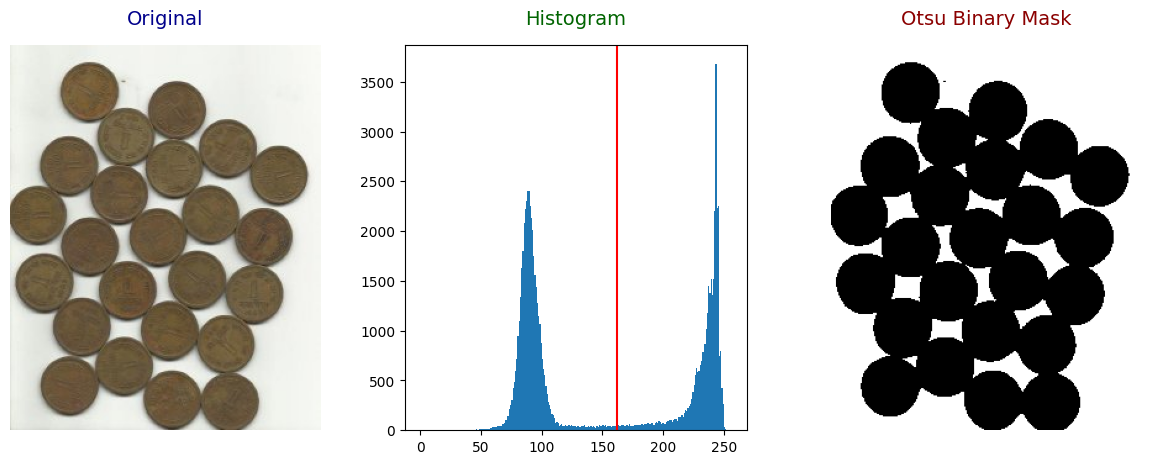

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title("Original", fontsize=14, color='darkblue', pad=15)

axes[1].hist(gray.ravel(), bins=256, range=(0, 256))
axes[1].axvline(t_otsu, color='red')
axes[1].set_title("Histogram", fontsize=14, color='darkgreen', pad=15)

axes[2].imshow(mask, cmap='gray')
axes[2].axis('off')
axes[2].set_title("Otsu Binary Mask", fontsize=14, color='darkred', pad=15)

plt.show()

Original - threshold: 162.0
Blurred - threshold: 162.0
Higher contrast - threshold: 194.0
Brighter - threshold: 196.0


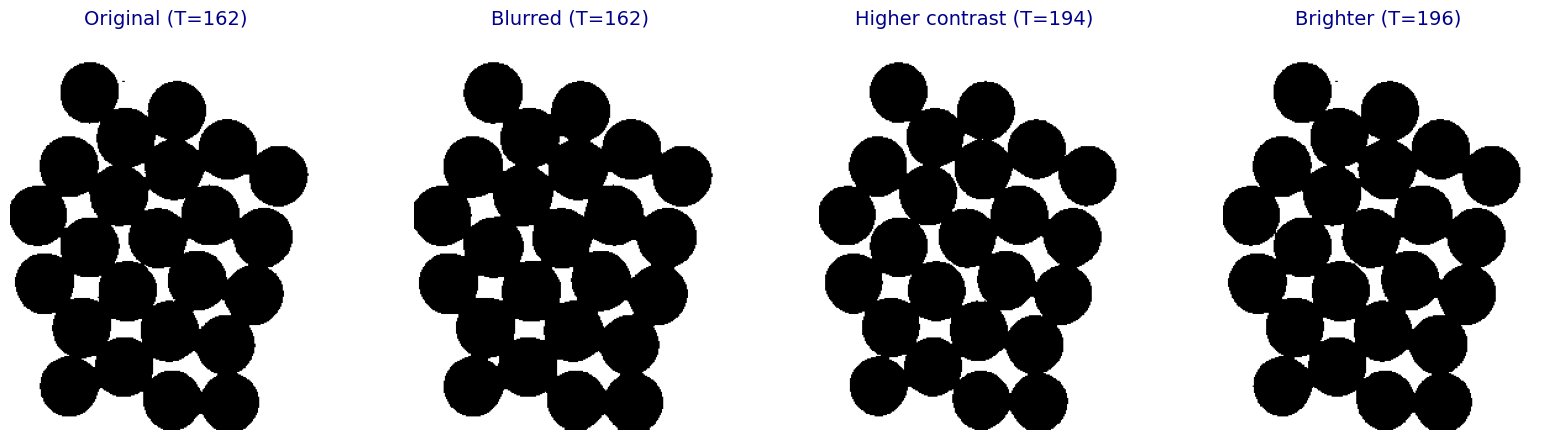

In [5]:
variants = {
    'Original': gray,
    'Blurred': cv2.GaussianBlur(gray, (5, 5), 0),
    'Higher contrast': cv2.convertScaleAbs(gray, alpha=1.5, beta=0),
    'Brighter': cv2.convertScaleAbs(gray, alpha=1, beta=50),
}

panels = []
for name, im in variants.items():
    t, m = cv2.threshold(im, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    print(name, '- threshold:', t)
    panels.append((f'{name} (T={t:.0f})', m))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [6]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task3_otsu.png', mask)

True

Otsu threshold is 162 for the original and the blurred image. With higher contrast it is 194 and with a brighter image 196. The histogram has two peaks (dark coins, bright paper) and Otsu puts the threshold between them every time. The mask barely changes.

Why is Otsu useful when the correct threshold is not known? It finds the threshold that separates the two groups of pixels best, so it adjusts to each image. A fixed value like 127 would not work for the brighter versions.